In [1]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from uncertainties import ufloat
from ctypes import c_double
from pathlib import Path
import pickle

# import ROOT
# ROOT.EnableImplicitMT()    # Tells ROOT to go parallel

/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_1065_epoch_18/tables')
SAMPLE = 'C1N2MLstudy_M400_388_ct20_2018_SP1_evt_MET_pt_corr_vs_SP1_Max_ML_score'

# HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_931_epoch_397_test1/tables')

# SAMPLE = 'stopMLstudy_M1000_988_ct20_2018'
# SAMPLE = 'C1N2MLstudy_M400_388_ct0p2_2018_SP2_evt_leading_vtx_ML1_vs_leading_vtx_ML2'
# SAMPLE = 'C1N2MLstudy_M400_388_ct20_2018_SP1_evt_leading_vtx_ML1_vs_leading_vtx_ML2'

TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)


In [3]:
table['0.00,0.00']['sig_NA']

,0.9501,0.9502,0.9503,0.9504,0.9505,0.9506,0.9507,0.9508,0.9509,0.9510,...,0.9991,0.9992,0.9993,0.9994,0.9995,0.9996,0.9997,0.9998,0.9999,1.0000
50.0,39.696109,39.645139,39.645139,39.645139,39.645139,39.645139,39.598427,39.598427,39.598427,39.498384,...,14.590356,14.080255,13.263369,12.240743,11.053499,9.884921,8.661790,6.817507,4.621176,1.171983
100.0,39.696109,39.645139,39.645139,39.645139,39.645139,39.645139,39.598427,39.598427,39.598427,39.498384,...,14.590356,14.080255,13.263369,12.240743,11.053499,9.884921,8.661790,6.817507,4.621176,1.171983
150.0,39.696109,39.645139,39.645139,39.645139,39.645139,39.645139,39.598427,39.598427,39.598427,39.498384,...,14.590356,14.080255,13.263369,12.240743,11.053499,9.884921,8.661790,6.817507,4.621176,1.171983
200.0,39.696109,39.645139,39.645139,39.645139,39.645139,39.645139,39.598427,39.598427,39.598427,39.498384,...,14.590356,14.080255,13.263369,12.240743,11.053499,9.884921,8.661790,6.817507,4.621176,1.171983
250.0,31.103488,31.052518,31.052518,31.052518,31.052518,31.052518,31.052518,31.052518,31.052518,31.000797,...,10.931131,10.624056,10.010574,9.236828,8.197729,7.493381,6.366492,4.962846,3.444443,0.866108
300.0,22.907266,22.856296,22.856296,22.856296,22.856296,22.856296,22.856296,22.856296,22.856296,22.804575,...,7.842138,7.584931,7.175557,6.555967,5.873057,5.465654,4.545606,3.554024,2.585998,0.668373
350.0,16.548670,16.497700,16.497700,16.497700,16.497700,16.497700,16.497700,16.497700,16.497700,16.445979,...,5.626709,5.369503,5.110356,4.692264,4.318087,4.014378,3.295985,2.677018,1.865509,0.668373
400.0,12.730585,12.730585,12.730585,12.730585,12.730585,12.730585,12.730585,12.730585,12.730585,12.678864,...,3.823383,3.772513,3.564605,3.406125,3.197229,2.992830,2.428031,1.861286,1.297656,0.562610
450.0,9.592515,9.592515,9.592515,9.592515,9.592515,9.592515,9.592515,9.592515,9.592515,9.592515,...,3.036767,3.036767,2.882323,2.775564,2.566669,2.362269,2.063027,1.547461,1.038393,0.409429
500.0,7.286582,7.286582,7.286582,7.286582,7.286582,7.286582,7.286582,7.286582,7.286582,7.286582,...,2.307855,2.307855,2.153411,2.097068,1.938959,1.842278,1.543036,1.027470,0.623329,0.311387


In [4]:
table['0.00,0.00']['Z_noncl_A'].loc[0.9:,0.9:].stack().idxmax()

(300.0, 0.9993999999999945)

In [5]:
xmin, xmax = 0.9, 1.0
ymin, ymax = 0.9, 1.0

b = table['0.00,0.00']['sig_NA'].loc[xmin:xmax, ymin:ymax]


fig = plt.figure()
pcm = ax.pcolormesh(b.index, b.columns, b.T,
        cmap="viridis", vmin=None, vmax=None, shading="auto")

cbar = fig.colorbar(pcm, shrink=0.90)
cbar.ax.set_ylabel(r"Events")
plt.show()

NameError: name 'ax' is not defined

<Figure size 640x480 with 0 Axes>

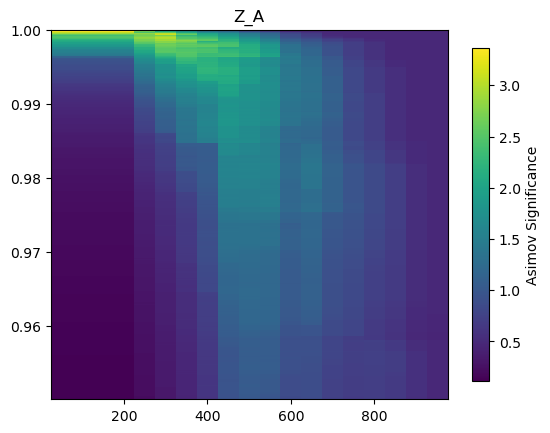

In [6]:
b = table['0.00,0.00']['Z_A']


fig = plt.figure()
pcm = plt.pcolormesh(b.index, b.columns, b.T,
        cmap="viridis", vmin=None, vmax=None, shading="auto")

cbar = fig.colorbar(pcm, shrink=0.90)
cbar.ax.set_ylabel(r"Asimov Significance")
plt.title('Z_A')
plt.show()

In [178]:
import ROOT
ROOT.RooStats.AsimovSignificance(10, 0.5, 0.5*0.2)

6.35958487998121

In [91]:
table.keys()

dict_keys(['0.00,0.00', '0.00,0.10', '0.00,0.20', '0.10,0.00', '0.10,0.10', '0.10,0.20', '0.20,0.00', '0.20,0.10', '0.20,0.20'])

In [92]:
table['0.00,0.00'].keys()

dict_keys(['sig_NA', 'sig_NB', 'sig_NC', 'sig_ND', 'bkg_NA', 'bkg_NB', 'bkg_NC', 'bkg_ND', 'sig_NA_unc', 'sig_NB_unc', 'sig_NC_unc', 'sig_ND_unc', 'bkg_NA_unc', 'bkg_NB_unc', 'bkg_NC_unc', 'bkg_ND_unc', 'Z_A', 'Z_B', 'Z_C', 'Z_D', 'Z_noncl_A', 'Z_noncl_B', 'Z_noncl_C', 'Z_noncl_D', 'noncl', 'noncl_unc'])

In [93]:
table['0.00,0.00']['bkg_NA'].loc[0.2, 0.8]

10859.738529423259

In [94]:
(table['0.00,0.00']['bkg_NB'].loc[0.2, 0.8] * 
 table['0.00,0.00']['bkg_NC'].loc[0.2, 0.8] /
 table['0.00,0.00']['bkg_ND'].loc[0.2, 0.8])

5006.340176044723

In [95]:
# fig = plt.figure()
# rel_err_f = (table['0.00,0.00']['bkg_NB'] * table['0.00,0.00']['bkg_NC']) / (table['0.00,0.00']['bkg_NA'] * table['0.00,0.00']['bkg_ND'])
# pcm = plt.pcolormesh(rel_err_f.index, rel_err_f.columns, rel_err_f.T,
#         cmap="viridis", vmin=0.5, vmax=2, shading="auto")
# plt.xlim(0.5, 1.0)
# plt.ylim(0.5, 1.0)
# 
# # Shared colorbar
# cbar = fig.colorbar(pcm, shrink=0.90)
# cbar.ax.set_ylabel(r"$(A - A_{pred}) / A$")
# plt.show()


### Non-Closure

In [96]:
np.any(noncl < 0)

False

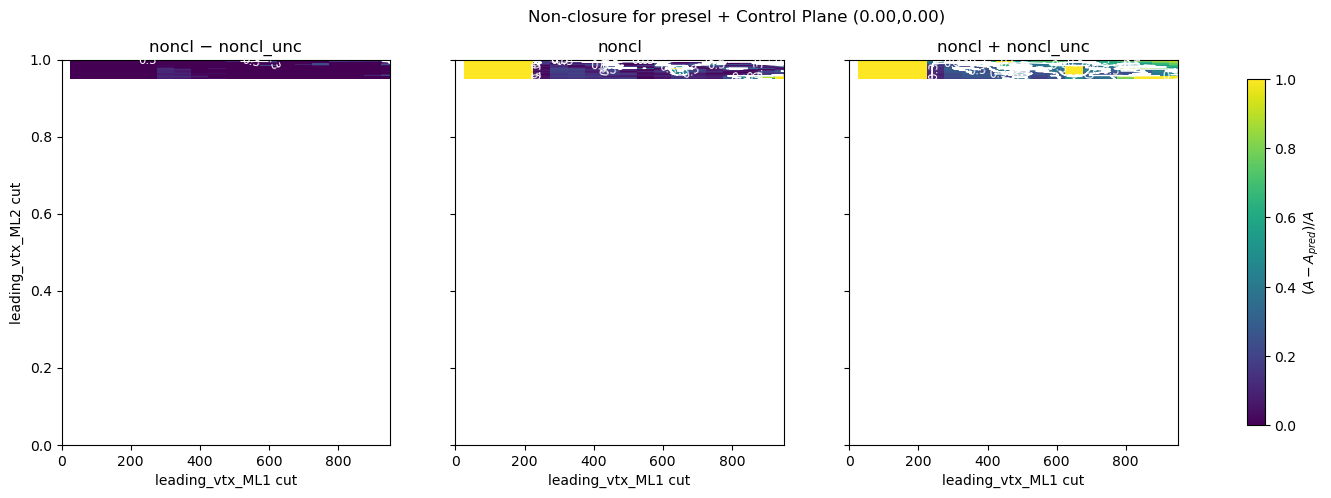

In [7]:
sig_tag = SAMPLE

def plot_pair(Z_noncl_minus, Z_noncl, Z_noncl_plus, suptitle):
    # Common contour levels
    # base_levels = [-0.30, 0.30]
    base_levels = [0.30, 0.50]
    global_max = np.nanmax([
        np.nanmax(Z_noncl_minus.values),
        np.nanmax(Z_noncl.values),
        np.nanmax(Z_noncl_plus.values)
    ])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Shared color scale
    # vmin = -1
    vmin = 0
    vmax =  1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(suptitle)

    # ---------------- LEFT: noncl - noncl_unc ----------------
    ax = axes[0]
    ax.set_title("noncl − noncl_unc")
    pcm0 = ax.pcolormesh(
        Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(
            Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont0, fontsize="smaller")
    ax.set_xlim(0., Z_noncl_minus.index.max())
    ax.set_ylim(0., Z_noncl_minus.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # ---------------- MIDDLE: noncl ----------------
    ax = axes[1]
    ax.set_title("noncl")
    pcm1 = ax.pcolormesh(
        Z_noncl.index, Z_noncl.columns, Z_noncl.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(
            Z_noncl.index, Z_noncl.columns, Z_noncl.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont1, fontsize="smaller")
    ax.set_xlim(0., Z_noncl.index.max())
    ax.set_ylim(0., Z_noncl.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")

    # ---------------- RIGHT: noncl + noncl_unc ----------------
    ax = axes[2]
    ax.set_title("noncl + noncl_unc")
    pcm2 = ax.pcolormesh(
        Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont2 = ax.contour(
            Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont2, fontsize="smaller")
    ax.set_xlim(0., Z_noncl_plus.index.max())
    ax.set_ylim(0., Z_noncl_plus.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm2, ax=axes.ravel().tolist(), shrink=0.90)
    cbar.ax.set_ylabel(r"$(A - A_{pred}) / A$")

    plt.show()


# --- Loop over all tables ---
for key, sub in table.items():
    noncl          = sub["noncl"]
    noncl_plus1s   = sub["noncl"] + sub["noncl_unc"]
    noncl_minus1s  = sub["noncl"] - sub["noncl_unc"]

    plot_pair(noncl_minus1s, noncl, noncl_plus1s, suptitle=f"Non-closure for presel + Control Plane ({key})")
    # print(np.any(noncl < 0))


### Plot only the range -0.20 < noncl < 0.20

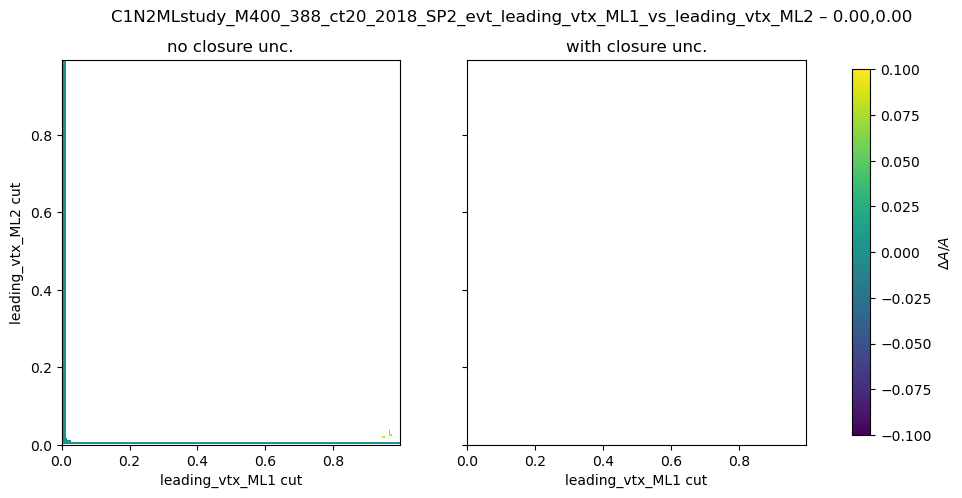

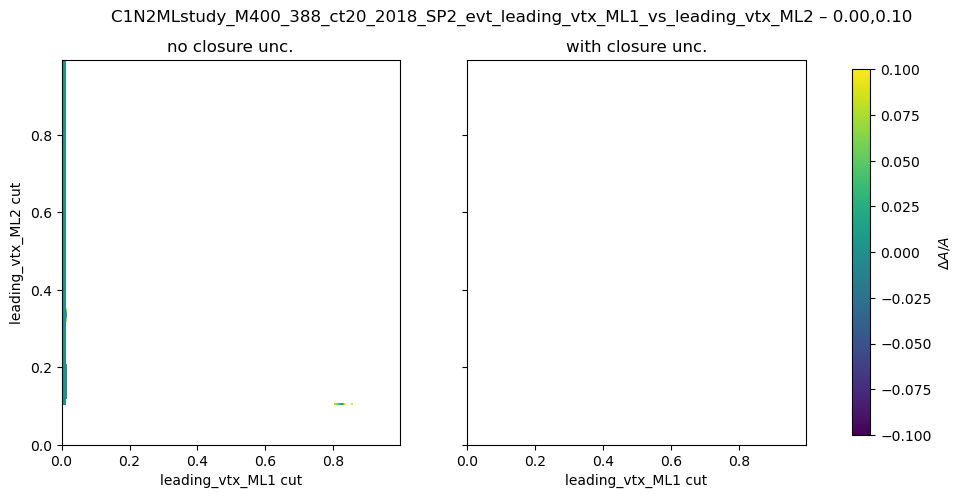

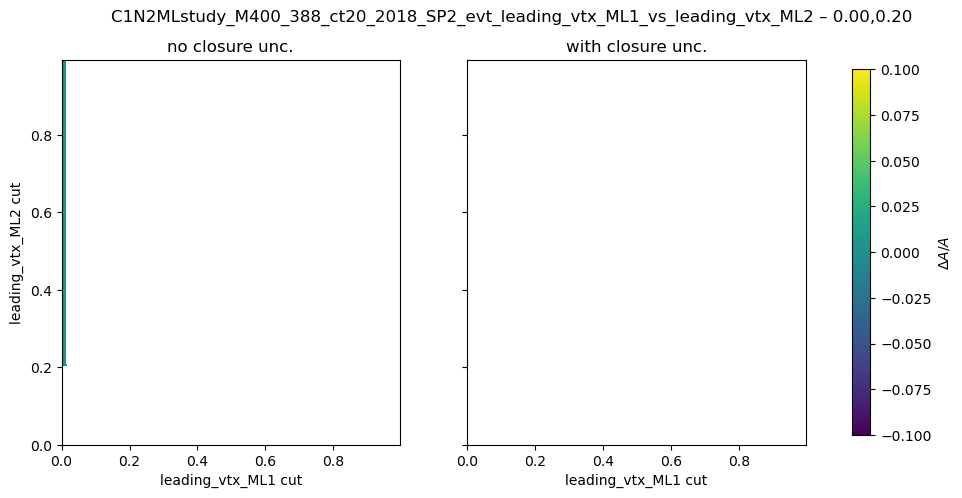

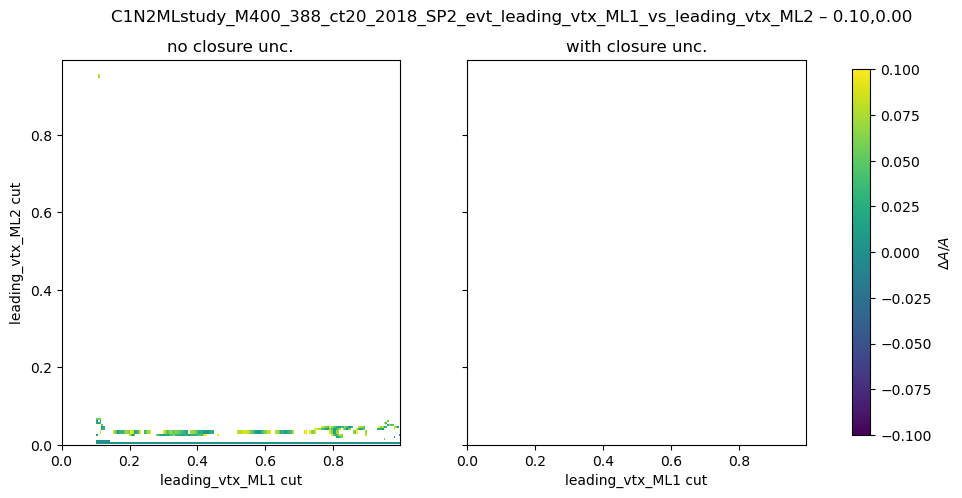

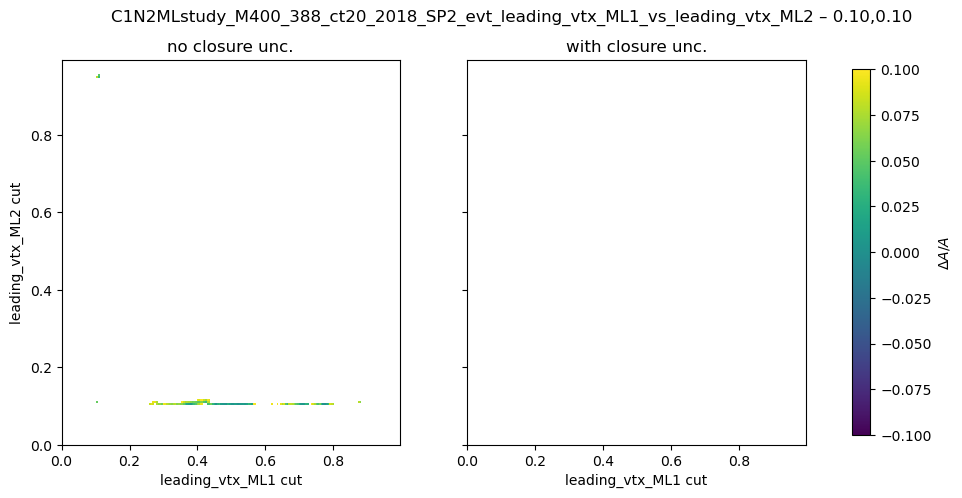

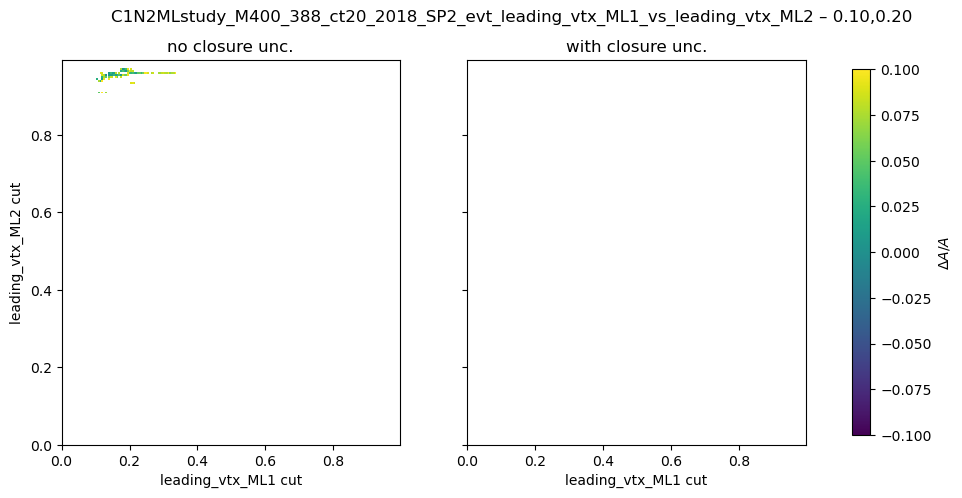

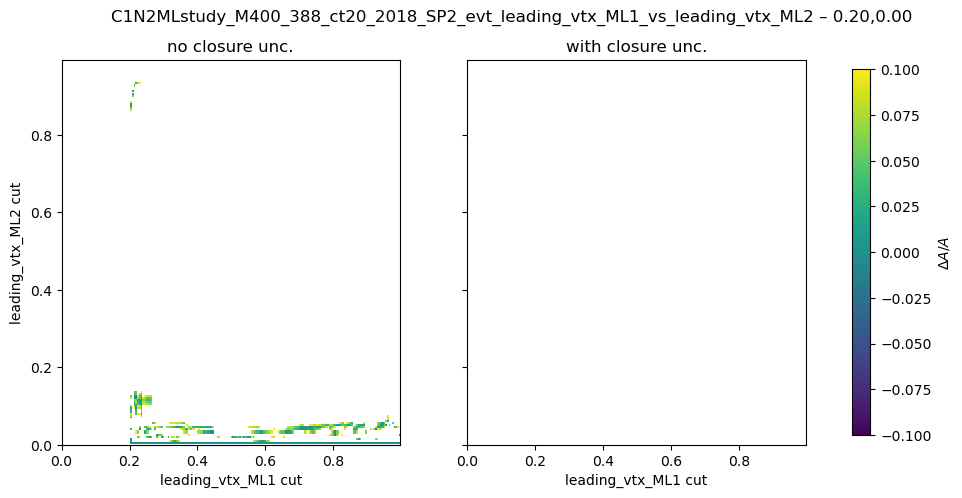

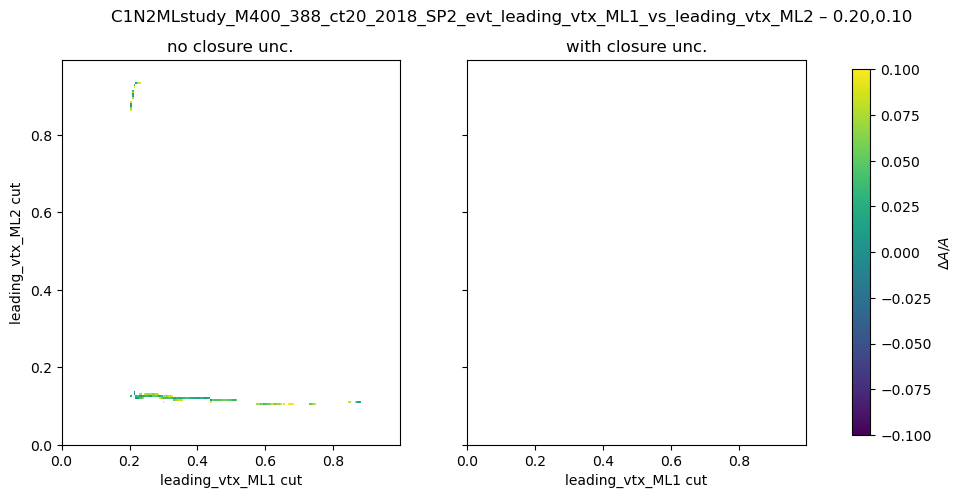

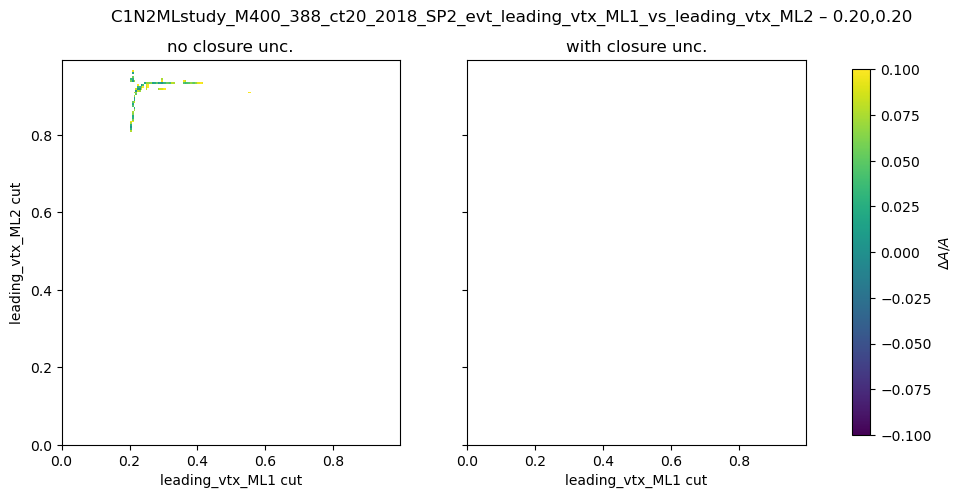

In [71]:
import numpy as np
import matplotlib.pyplot as plt

sig_tag = SAMPLE  # keep your original variable

def plot_pair(Z_left, Z_right, sig_tag):
    # Range of interest
    low, high = -0.1, 0.1

    # Common levels based on both matrices
    base_levels = [low, high]
    global_max = np.nanmax([np.nanmax(Z_left.values), np.nanmax(Z_right.values)])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Mask values outside the region of interest (without modifying originals)
    Z_left_vals = Z_left.values
    Z_right_vals = Z_right.values

    Zmasked_left = np.ma.masked_outside(Z_left_vals,  low, high)
    Zmasked_right = np.ma.masked_outside(Z_right_vals, low, high)

    # Color scale: limited to the range of interest
    vmin = low
    vmax = high

    # Optional: show masked values as light grey if they appear
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="white")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle(sig_tag)

    # --- Left ---
    ax = axes[0]
    ax.set_title("no closure unc.")
    pcm0 = ax.pcolormesh(
        Z_left.index, Z_left.columns, Zmasked_left.T,
        cmap=cmap, vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(
            Z_left.index, Z_left.columns, Zmasked_left.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont0, fontsize="smaller")
    ax.set_xlim(0., Z_left.index.max())
    ax.set_ylim(0., Z_left.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # --- Right ---
    ax = axes[1]
    ax.set_title("with closure unc.")
    pcm1 = ax.pcolormesh(
        Z_right.index, Z_right.columns, Zmasked_right.T,
        cmap=cmap, vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(
            Z_right.index, Z_right.columns, Zmasked_right.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont1, fontsize="smaller")
    ax.set_xlim(0., Z_right.index.max())
    ax.set_ylim(0., Z_right.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm1, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.ax.set_ylabel(r"$\Delta A / A$")

    # plt.tight_layout()
    plt.show()


# --- Loop over your dictionary of tables ---

for key, sub in table.items():
    noncl        = sub["noncl"]
    noncl_plus1s = sub["noncl"] + sub["noncl_unc"]

    plot_pair(noncl, noncl_plus1s, sig_tag=f"{sig_tag} – {key}")


### Significance

In [130]:
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_931_epoch_397_test1/tables')
SAMPLE = 'C1N2MLstudy_M400_388_ct20_2018_SP1_evt_leading_vtx_ML1_vs_leading_vtx_ML2'
# SAMPLE = 'stop_M600_588_ct20_2018'
TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)

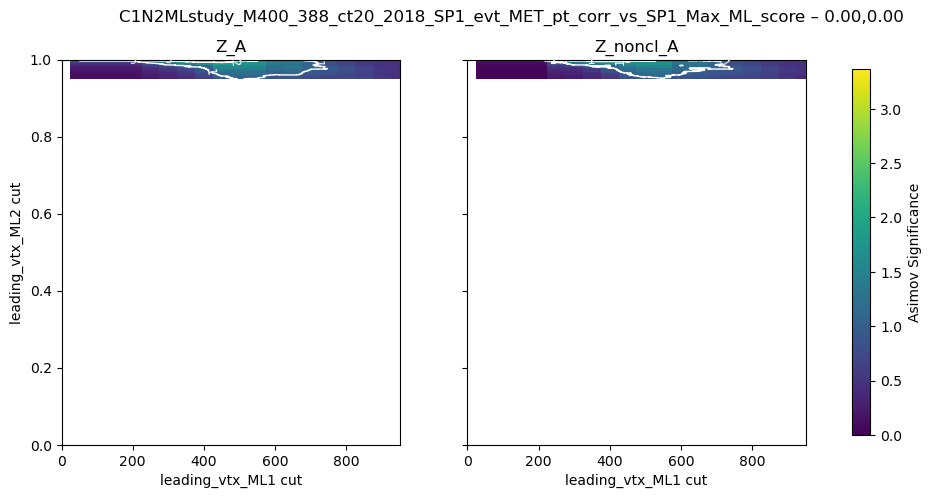

In [8]:
sig_tag = SAMPLE

def plot_pair(Z_left, Z_right, sig_tag):
    # Common levels based on both matrices
    base_levels = [1, 2, 3]
    global_max = np.nanmax([np.nanmax(Z_left.values), np.nanmax(Z_right.values)])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Consistent color scale across both plots
    vmin = 0 # np.nanmin([np.nanmin(Z_left.values), np.nanmin(Z_right.values)])
    vmax = global_max

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle(sig_tag)

    # --- Left ---
    ax = axes[0]
    ax.set_title('Z_A')
    pcm0 = ax.pcolormesh(
        Z_left.index, Z_left.columns, Z_left.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(Z_left.index, Z_left.columns, Z_left.T,
                           levels=levels, colors="white", linewidths=1.0, linestyles="solid")
        ax.clabel(cont0, fontsize="smaller")
    ax.set_xlim(0.0, Z_left.index.max())
    ax.set_ylim(0.0, Z_left.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # --- Right ---
    ax = axes[1]
    ax.set_title('Z_noncl_A')
    pcm1 = ax.pcolormesh(
        Z_right.index, Z_right.columns, Z_right.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(Z_right.index, Z_right.columns, Z_right.T,
                           levels=levels, colors="white", linewidths=1.0, linestyles="solid")
        ax.clabel(cont1, fontsize="smaller")
    ax.set_xlim(0.0, Z_right.index.max())
    ax.set_ylim(0.0, Z_right.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm1, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.ax.set_ylabel(r"Asimov Significance")

    # plt.tight_layout()
    plt.show()


# --- Loop over your dictionary of tables ---

for key, sub in table.items():
    noncl        = sub['Z_A']
    noncl_plus1s = sub['Z_noncl_A']

    plot_pair(noncl, noncl_plus1s, sig_tag=f"{sig_tag} – {key}")


### C1N2

In [105]:
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_931_epoch_397_test1/tables')
SAMPLE = 'C1N2MLstudy_M400_388_ct20_2018_SP2_evt_leading_vtx_ML1_vs_leading_vtx_ML2'
# SAMPLE = 'stop_M600_588_ct20_2018'
TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)

In [106]:
tables = table['0.00,0.00']

x_max, y_max = tables['Z_noncl_A'].stack().idxmax()

print(f'Best cut values: {x_max}, {y_max}')
print(f'nonclosure: {tables["noncl"].loc[x_max, y_max]} +/- {tables["noncl_unc"].loc[x_max, y_max]}')
print('significance without non-closure unc.:', tables['Z_A'].loc[x_max, y_max])
print('significance with non-closure unc.:', tables['Z_noncl_A'].loc[x_max, y_max])
print()
print('Signal counts in A:', tables['sig_NA'].loc[x_max, y_max])
print('Background counts in A:', tables['bkg_NA'].loc[x_max, y_max])

Best cut values: 0.005, 0.995
nonclosure: 0.0 +/- 1.0
significance without non-closure unc.: 1.5062037550123348
significance with non-closure unc.: 1.5062037550123348

Signal counts in A: 5.346481918646571
Background counts in A: 3.8824146717468158


In [107]:
tables = table['0.00,0.00']

x_max, y_max = 0.9450000000000001, 0.985

print(f'Best cut values: {x_max}, {y_max}')
print(f'nonclosure: {tables["noncl"].loc[x_max, y_max]} +/- {tables["noncl_unc"].loc[x_max, y_max]}')
print('significance without non-closure unc.:', tables['Z_A'].loc[x_max, y_max])
print('significance with non-closure unc.:', tables['Z_noncl_A'].loc[x_max, y_max])
print()
print('Signal counts in A:', tables['sig_NA'].loc[x_max, y_max])
print('Background counts in A:', tables['bkg_NA'].loc[x_max, y_max])

Best cut values: 0.9450000000000001, 0.985
nonclosure: 0.9864191929418417 +/- 0.01020798286532061
significance without non-closure unc.: 1.6142232064122408
significance with non-closure unc.: 0.8411620126546832

Signal counts in A: 6.199038614719246
Background counts in A: 4.727666264572363


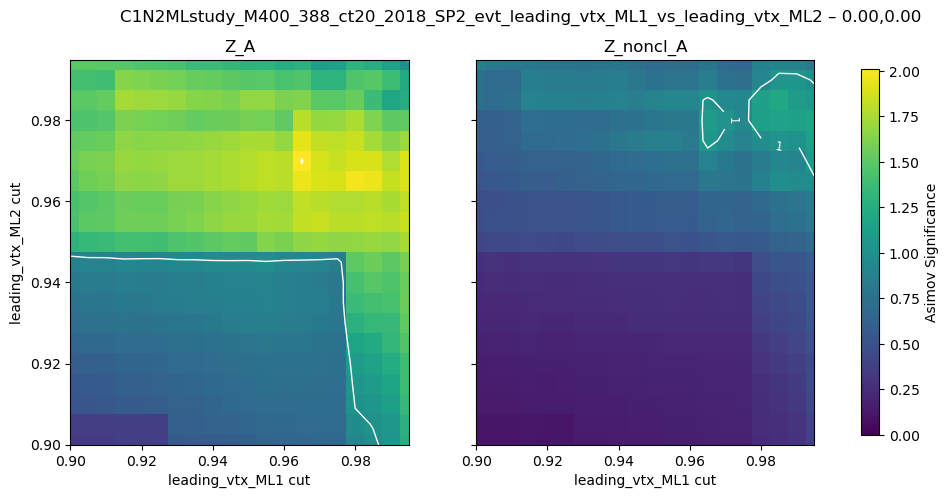

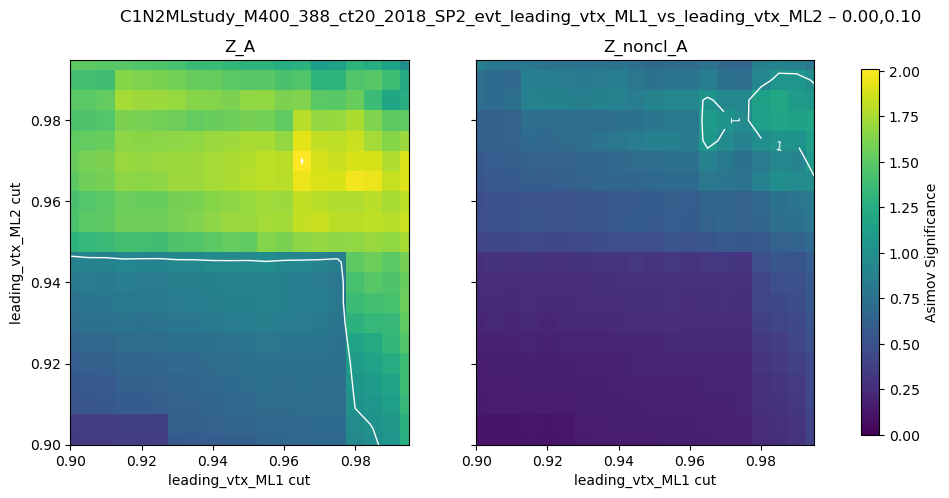

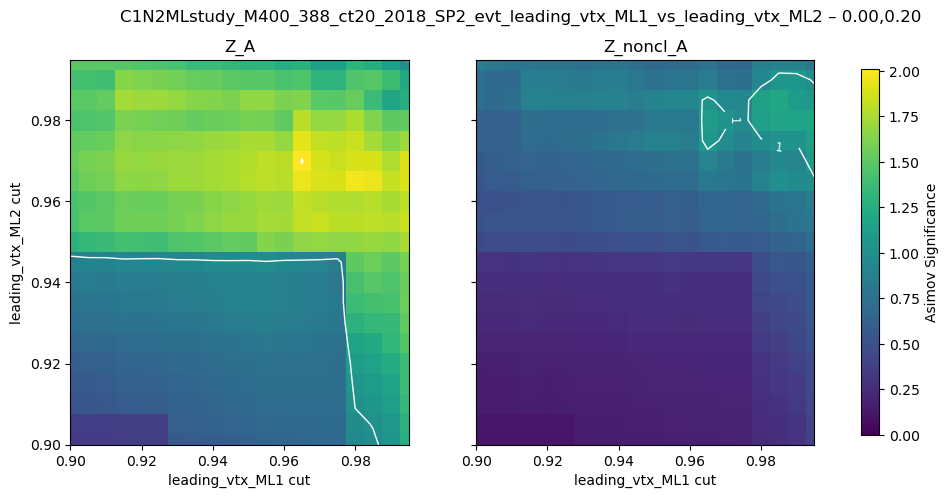

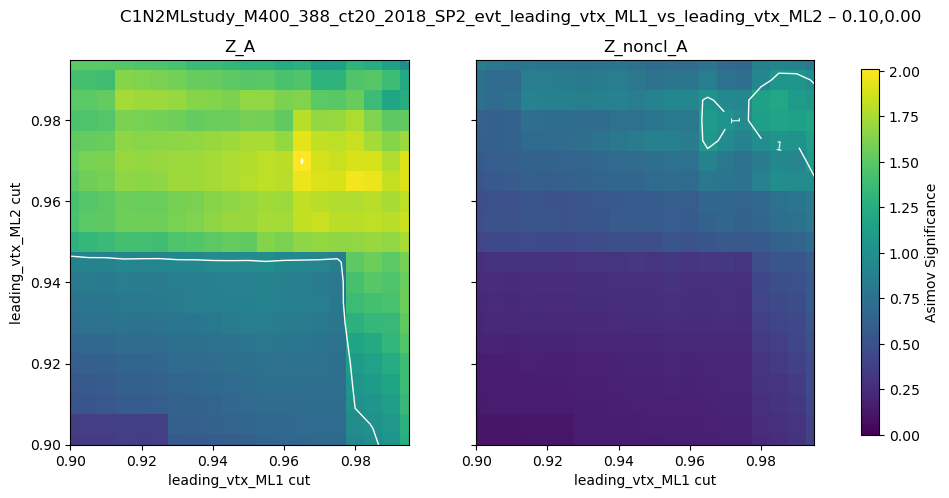

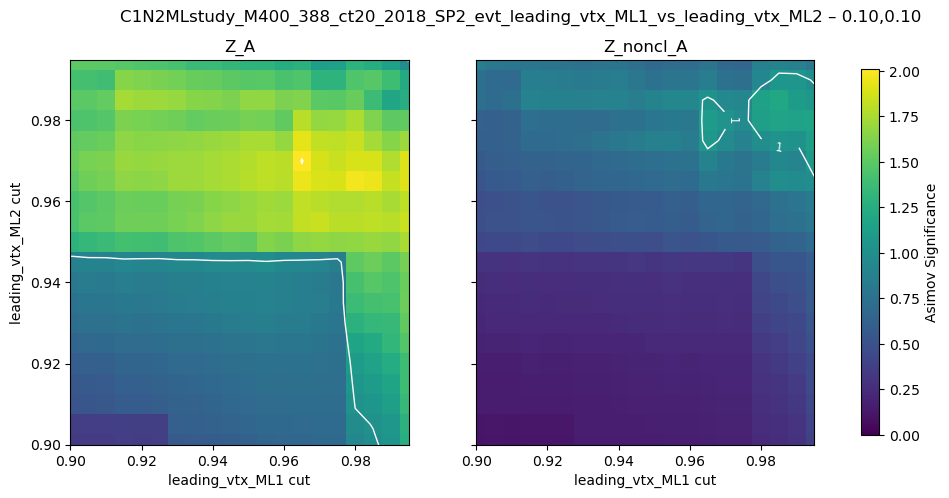

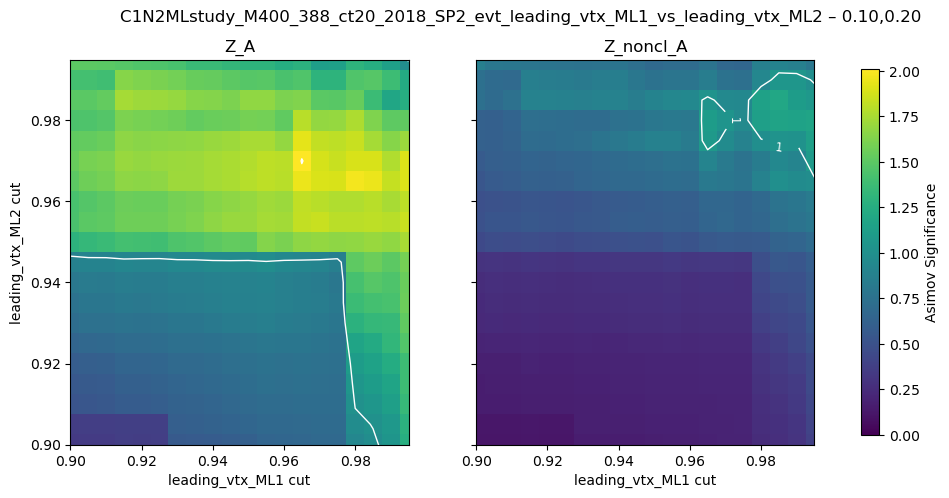

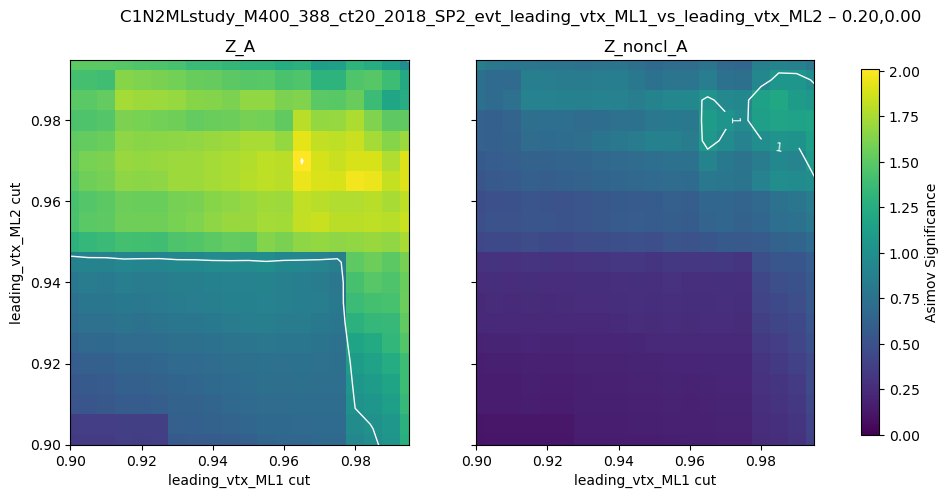

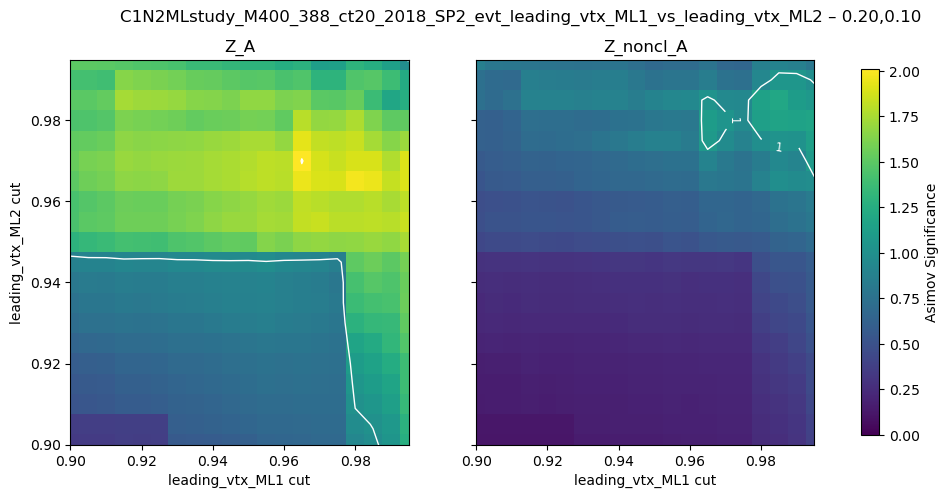

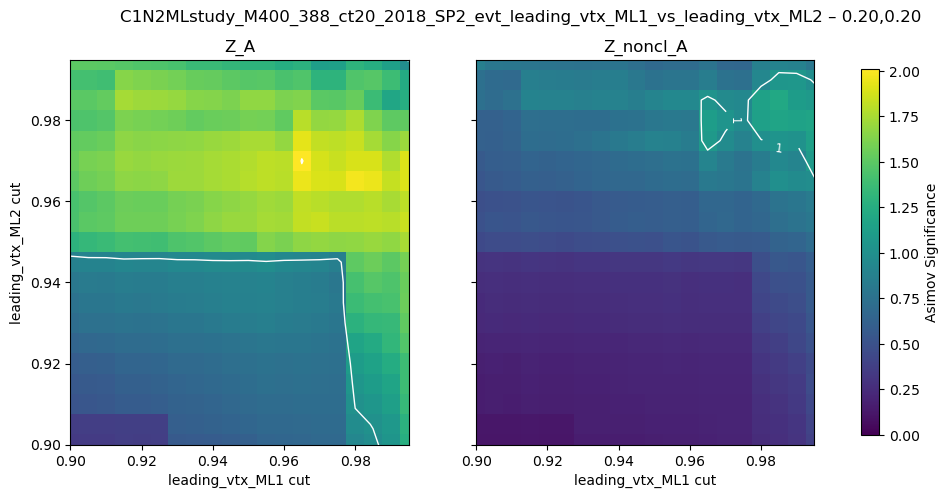

In [108]:
sig_tag = SAMPLE

def plot_pair(Z_left, Z_right, sig_tag):
    # Common levels based on both matrices
    base_levels = [1, 2, 3]
    global_max = np.nanmax([np.nanmax(Z_left.values), np.nanmax(Z_right.values)])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Consistent color scale across both plots
    vmin = 0 # np.nanmin([np.nanmin(Z_left.values), np.nanmin(Z_right.values)])
    vmax = global_max

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle(sig_tag)

    # --- Left ---
    ax = axes[0]
    ax.set_title('Z_A')
    pcm0 = ax.pcolormesh(
        Z_left.index, Z_left.columns, Z_left.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(Z_left.index, Z_left.columns, Z_left.T,
                           levels=levels, colors="white", linewidths=1.0, linestyles="solid")
        ax.clabel(cont0, fontsize="smaller")
    ax.set_xlim(0.9, Z_left.index.max())
    ax.set_ylim(0.9, Z_left.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # --- Right ---
    ax = axes[1]
    ax.set_title('Z_noncl_A')
    pcm1 = ax.pcolormesh(
        Z_right.index, Z_right.columns, Z_right.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(Z_right.index, Z_right.columns, Z_right.T,
                           levels=levels, colors="white", linewidths=1.0, linestyles="solid")
        ax.clabel(cont1, fontsize="smaller")
    ax.set_xlim(0.9, Z_right.index.max())
    ax.set_ylim(0.9, Z_right.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm1, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.ax.set_ylabel(r"Asimov Significance")

    # plt.tight_layout()
    plt.show()


# --- Loop over your dictionary of tables ---

for key, sub in table.items():
    noncl        = sub['Z_A']
    noncl_plus1s = sub['Z_noncl_A']

    plot_pair(noncl, noncl_plus1s, sig_tag=f"{sig_tag} – {key}")


# Closure in data

In [ ]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from uncertainties import ufloat
from ctypes import c_double
from pathlib import Path
import pickle

# import ROOT
# ROOT.EnableImplicitMT()    # Tells ROOT to go parallel


HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_859_epoch_87_blind/tables')
SAMPLE = 'C1N2MLstudy_M400_388_ct20_2018_SP1_evt_withdata'
TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)


In [ ]:
table['0.00,0.00'].keys()

dict_keys(['sig_NA', 'sig_NB', 'sig_NC', 'sig_ND', 'bkg_NA', 'bkg_NB', 'bkg_NC', 'bkg_ND', 'sig_NA_unc', 'sig_NB_unc', 'sig_NC_unc', 'sig_ND_unc', 'bkg_NA_unc', 'bkg_NB_unc', 'bkg_NC_unc', 'bkg_ND_unc', 'Z_A', 'Z_B', 'Z_C', 'Z_D', 'Z_noncl_A', 'Z_noncl_B', 'Z_noncl_C', 'Z_noncl_D', 'noncl', 'noncl_unc'])

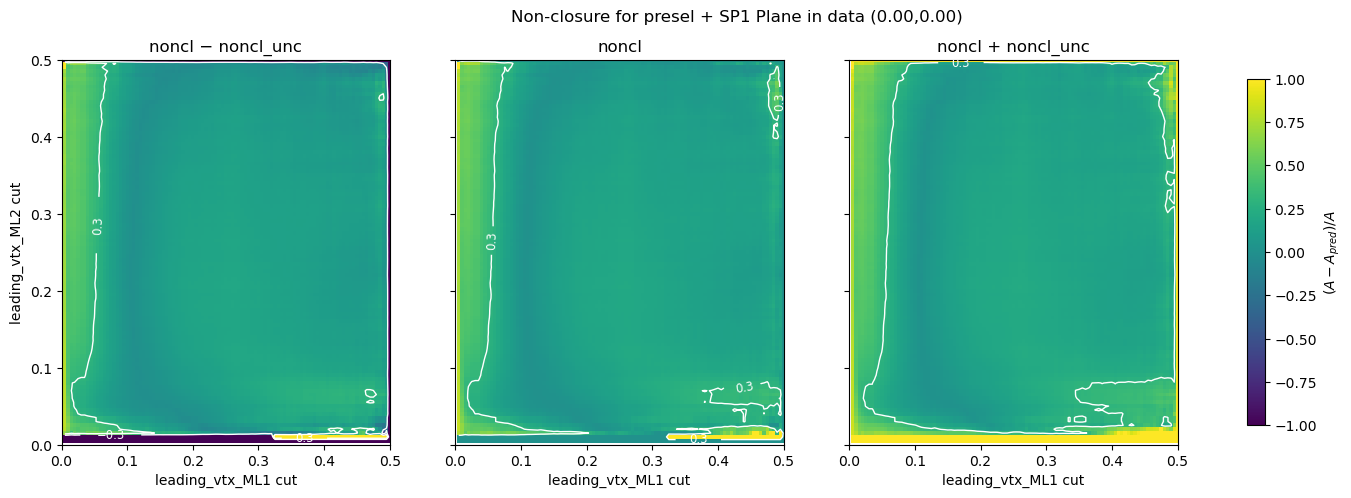

In [ ]:
def plot_pair(Z_noncl_minus, Z_noncl, Z_noncl_plus, suptitle):
    # Common contour levels
    base_levels = [-0.30, 0.30]
    global_max = np.nanmax([
        np.nanmax(Z_noncl_minus.values),
        np.nanmax(Z_noncl.values),
        np.nanmax(Z_noncl_plus.values)
    ])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Shared color scale
    vmin = -1
    vmax =  1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(suptitle)

    # ---------------- LEFT: noncl - noncl_unc ----------------
    ax = axes[0]
    ax.set_title("noncl − noncl_unc")
    pcm0 = ax.pcolormesh(
        Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(
            Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont0, fontsize="smaller")
    ax.set_xlim(0., 0.5)
    ax.set_ylim(0., 0.5)
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # ---------------- MIDDLE: noncl ----------------
    ax = axes[1]
    ax.set_title("noncl")
    pcm1 = ax.pcolormesh(
        Z_noncl.index, Z_noncl.columns, Z_noncl.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(
            Z_noncl.index, Z_noncl.columns, Z_noncl.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont1, fontsize="smaller")
    ax.set_xlim(0., 0.5)
    ax.set_ylim(0., 0.5)
    ax.set_xlabel("leading_vtx_ML1 cut")

    # ---------------- RIGHT: noncl + noncl_unc ----------------
    ax = axes[2]
    ax.set_title("noncl + noncl_unc")
    pcm2 = ax.pcolormesh(
        Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont2 = ax.contour(
            Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont2, fontsize="smaller")
    ax.set_xlim(0., 0.5)
    ax.set_ylim(0., 0.5)
    ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm2, ax=axes.ravel().tolist(), shrink=0.90)
    cbar.ax.set_ylabel(r"$(A - A_{pred}) / A$")

    plt.show()


# --- Loop over all tables ---
for key, sub in table.items():
    noncl          = sub["noncl"]
    noncl_plus1s   = sub["noncl"] + sub["noncl_unc"]
    noncl_minus1s  = sub["noncl"] - sub["noncl_unc"]

    plot_pair(noncl_minus1s, noncl, noncl_plus1s, suptitle=f"Non-closure for presel + SP1 Plane in data ({key})")


In [ ]:
table['0.00,0.00']['Z_A'].loc[:0.495,:0.495]

,0.005,0.010,0.015,0.020,0.025,0.030,0.035,0.040,0.045,0.050,...,0.450,0.455,0.460,0.465,0.470,0.475,0.480,0.485,0.490,0.495
0.005,0.000538,0.000538,0.000538,0.000540,0.000544,0.000546,0.000546,0.000557,0.000563,0.000567,...,0.001068,0.001155,0.001103,0.001033,0.001159,0.001271,0.001100,0.001146,0.001685,0.003186
0.010,0.000535,0.000535,0.000536,0.000537,0.000541,0.000544,0.000544,0.000554,0.000560,0.000564,...,0.001049,0.001133,0.001118,0.001047,0.001174,0.001287,0.001114,0.001160,0.001710,0.003218
0.015,0.000539,0.000539,0.000540,0.000541,0.000545,0.000548,0.000548,0.000559,0.000565,0.000569,...,0.001059,0.001144,0.001128,0.001056,0.001185,0.001297,0.001124,0.001169,0.001723,0.003227
0.020,0.000544,0.000544,0.000545,0.000546,0.000550,0.000553,0.000553,0.000564,0.000570,0.000574,...,0.001066,0.001151,0.001135,0.001063,0.001193,0.001306,0.001130,0.001176,0.001733,0.003235
0.025,0.000550,0.000550,0.000551,0.000552,0.000556,0.000559,0.000559,0.000570,0.000576,0.000580,...,0.001075,0.001160,0.001144,0.001071,0.001202,0.001314,0.001139,0.001185,0.001745,0.003252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.475,0.000603,0.000603,0.000604,0.000607,0.000611,0.000619,0.000619,0.000644,0.000658,0.000675,...,0.012848,0.014335,0.015602,0.018259,0.021267,0.023522,0.028174,0.033270,0.043895,0.073494
0.480,0.000710,0.000710,0.000711,0.000714,0.000718,0.000729,0.000729,0.000757,0.000772,0.000793,...,0.017236,0.019111,0.020552,0.023751,0.028174,0.030697,0.036912,0.041518,0.053230,0.090658
0.485,0.000939,0.000939,0.000941,0.000944,0.000949,0.000964,0.000964,0.001003,0.001025,0.001050,...,0.023297,0.024972,0.026329,0.029560,0.034734,0.037503,0.045650,0.053230,0.064326,0.100747
0.490,0.001441,0.001441,0.001443,0.001448,0.001457,0.001480,0.001480,0.001536,0.001566,0.001604,...,0.033743,0.036341,0.038746,0.044754,0.050794,0.054548,0.064326,0.076292,0.095373,0.122905


In [ ]:
up_lim = 0.495
tables = table['0.00,0.00']
if_signal_present = tables['sig_NA'].loc[:up_lim,:up_lim] != 0.
tables['Z_A'].loc[:up_lim,:up_lim][if_signal_present]


print(f'Best cut values: {x_max}, {y_max}')
print(f'nonclosure: {tables["noncl"].loc[x_max, y_max]} +/- {tables["noncl_unc"].loc[x_max, y_max]}')
print('significance without non-closure unc.:', tables['Z_A'].loc[x_max, y_max])
print('significance with non-closure unc.:', tables['Z_noncl_A'].loc[x_max, y_max])
print()
print('Signal counts in A:', tables['sig_NA'].loc[x_max, y_max])
print('Background counts in A:', tables['bkg_NA'].loc[x_max, y_max])

Best cut values: 0.4, 0.4
nonclosure: 0.12420376360392993 +/- 0.029028245611914586
significance without non-closure unc.: 0.001329079016626034
significance with non-closure unc.: 0.0011332166837616146

Signal counts in A: 0.30751772945747086
Background counts in A: 1856.0


In [ ]:
table_data = table

### MC to compare

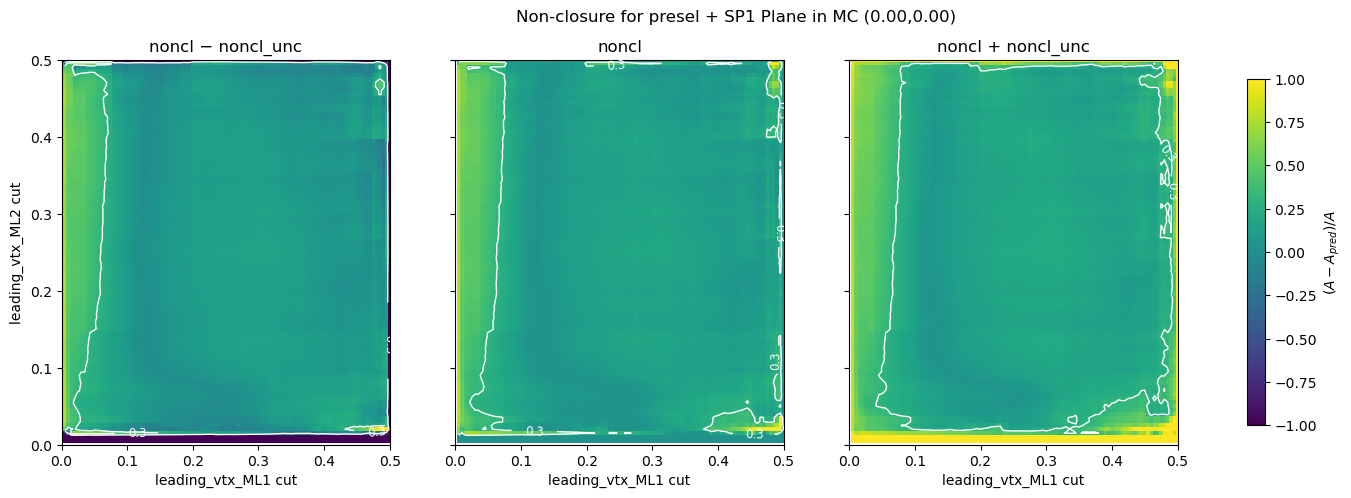

In [ ]:
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_859_epoch_87_blind/tables')
SAMPLE = 'C1N2MLstudy_M400_388_ct20_2018_SP1_evt'
TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)

# --- Loop over all tables ---
for key, sub in table.items():
    noncl          = sub["noncl"]
    noncl_plus1s   = sub["noncl"] + sub["noncl_unc"]
    noncl_minus1s  = sub["noncl"] - sub["noncl_unc"]

    plot_pair(noncl_minus1s, noncl, noncl_plus1s, suptitle=f"Non-closure for presel + SP1 Plane in MC ({key})")

In [ ]:
up_lim = 0.495
tables = table['0.00,0.00']
if_signal_present = tables['sig_NA'].loc[:up_lim,:up_lim] != 0.
tables['Z_A'].loc[:up_lim,:up_lim][if_signal_present]


print(f'Best cut values: {x_max}, {y_max}')
print(f'nonclosure: {tables["noncl"].loc[x_max, y_max]} +/- {tables["noncl_unc"].loc[x_max, y_max]}')
print('significance without non-closure unc.:', tables['Z_A'].loc[x_max, y_max])
print('significance with non-closure unc.:', tables['Z_noncl_A'].loc[x_max, y_max])
print()
print('Signal counts in A:', tables['sig_NA'].loc[x_max, y_max])
print('Background counts in A:', tables['bkg_NA'].loc[x_max, y_max])

Best cut values: 0.4, 0.4
nonclosure: 0.1252217395177022 +/- 0.05888399034867424
significance without non-closure unc.: 0.001996094829154749
significance with non-closure unc.: 0.0017088001671161175

Signal counts in A: 0.30751772945747086
Background counts in A: 1207.5628415417304


In [ ]:
delta_noncl = table_data['0.00,0.00']['noncl'] - table['0.00,0.00']['noncl']

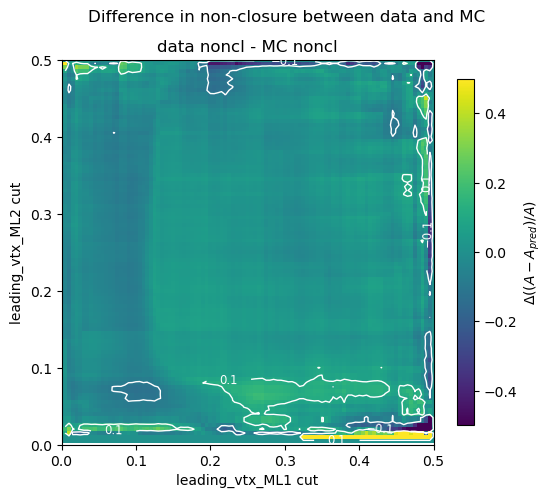

In [ ]:
def plot_single(Z, suptitle, title="noncl"):
    # Common contour levels
    base_levels = [-0.10, 0.10]
    global_max = np.nanmax(Z.values)
    levels = [lv for lv in base_levels if lv <= global_max]

    # Shared color scale
    vmin = -0.5
    vmax =  0.5

    fig, ax = plt.subplots(figsize=(6, 5))
    fig.suptitle(suptitle)

    ax.set_title(title)
    pcm = ax.pcolormesh(
        Z.index, Z.columns, Z.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont = ax.contour(
            Z.index, Z.columns, Z.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont, fontsize="smaller")

    ax.set_xlim(0., 0.5)
    ax.set_ylim(0., 0.5)
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # Colorbar
    cbar = fig.colorbar(pcm, ax=ax, shrink=0.90)
    cbar.ax.set_ylabel(r"$\Delta ((A - A_{pred}) / A)$")

    plt.show()

plot_single(delta_noncl, suptitle="Difference in non-closure between data and MC", title="data noncl - MC noncl")


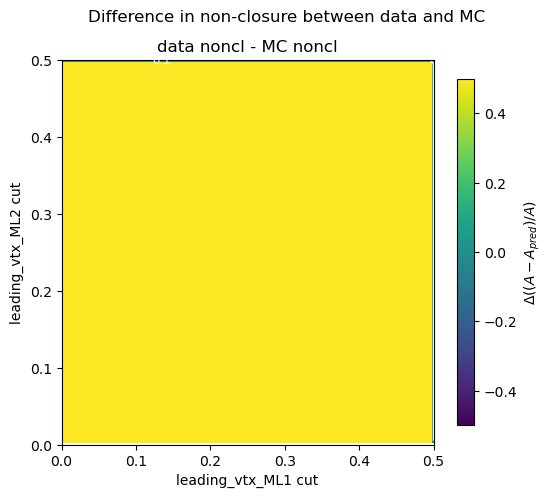

In [ ]:
def plot_single(Z, suptitle, title="noncl"):
    # Common contour levels
    base_levels = [-0.10, 0.10]
    global_max = np.nanmax(Z.values)
    levels = [lv for lv in base_levels if lv <= global_max]

    # Shared color scale
    vmin = -0.5
    vmax =  0.5

    fig, ax = plt.subplots(figsize=(6, 5))
    fig.suptitle(suptitle)

    ax.set_title(title)
    pcm = ax.pcolormesh(
        Z.index, Z.columns, Z.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont = ax.contour(
            Z.index, Z.columns, Z.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont, fontsize="smaller")

    ax.set_xlim(0., 0.5)
    ax.set_ylim(0., 0.5)
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # Colorbar
    cbar = fig.colorbar(pcm, ax=ax, shrink=0.90)
    cbar.ax.set_ylabel(r"$\Delta ((A - A_{pred}) / A)$")

    plt.show()

plot_single(delta_noncl, suptitle="Difference in non-closure between data and MC", title="data noncl - MC noncl")



plot_single(table_data['0.00,0.00']['bkg_NA'], suptitle="Difference in non-closure between data and MC", title="data noncl - MC noncl")

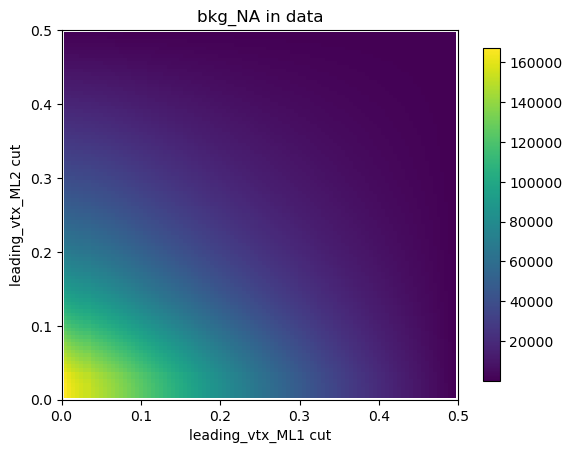

In [ ]:
X_d = table_data['0.00,0.00']['bkg_NA']
X_d[X_d == 0] = np.nan

fig = plt.figure()

pcm = plt.pcolormesh(X_d.index, X_d.columns, X_d.T,
                     cmap="viridis", shading="nearest"
                     )
plt.xlim(0., 0.5)
plt.ylim(0., 0.5)
cbar = fig.colorbar(pcm, shrink=0.90)
plt.title('bkg_NA in data')
plt.xlabel("leading_vtx_ML1 cut")
plt.ylabel("leading_vtx_ML2 cut")
plt.show()

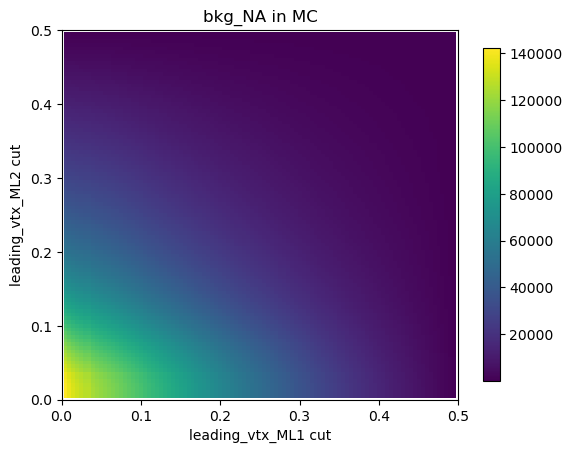

In [ ]:
X_b = table['0.00,0.00']['bkg_NA']
X_b[X_b == 0] = np.nan

fig = plt.figure()

pcm = plt.pcolormesh(X_b.index, X_b.columns, X_b.T,
                     cmap="viridis", shading="auto"
                     )
plt.xlim(0., 0.5)
plt.ylim(0., 0.5)
cbar = fig.colorbar(pcm, shrink=0.90)
plt.title('bkg_NA in MC')
plt.xlabel("leading_vtx_ML1 cut")
plt.ylabel("leading_vtx_ML2 cut")
plt.show()

In [ ]:
# R = X_d / X_b

# fig = plt.figure()

# pcm = plt.pcolormesh(R.index, R.columns, R.T,
#                      cmap="viridis", vmin=0, vmax=2, shading="auto"
#                      )
# plt.xlim(0., 0.5)
# plt.ylim(0., 0.5)
# cbar = fig.colorbar(pcm, shrink=0.90)
# plt.title('Data / MC ratio of background counts in A')
# plt.xlabel("leading_vtx_ML1 cut")
# plt.ylabel("leading_vtx_ML2 cut")
# plt.show()

## CP_evt

In [179]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from uncertainties import ufloat
from ctypes import c_double
from pathlib import Path
import pickle

HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_859_epoch_87_test3_reverse/tables')
SAMPLE = 'C1N2MLstudy_M400_388_ct20_2018_CP_evt_leading_vtx_ML1_vs_leading_vtx_ML2'
TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)


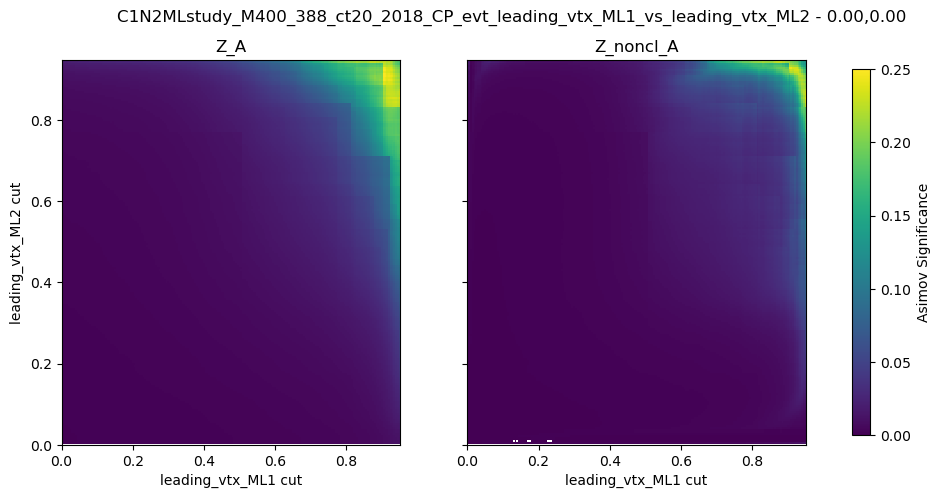

In [180]:
sig_tag = SAMPLE

def plot_pair(Z_left, Z_right, sig_tag):
    # Common levels based on both matrices
    base_levels = [1, 2, 3]
    global_max = np.nanmax([np.nanmax(Z_left.values), np.nanmax(Z_right.values)])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Consistent color scale across both plots
    vmin = 0 # np.nanmin([np.nanmin(Z_left.values), np.nanmin(Z_right.values)])
    vmax = 0.25 # global_max# 0.1# global_max

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle(sig_tag)

    # --- Left ---
    ax = axes[0]
    ax.set_title('Z_A')
    pcm0 = ax.pcolormesh(
        Z_left.index, Z_left.columns, Z_left.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(Z_left.index, Z_left.columns, Z_left.T,
                           levels=levels, colors="white", linewidths=1.0, linestyles="solid")
        ax.clabel(cont0, fontsize="smaller")
    ax.set_xlim(0.0, 0.95) # Z_left.index.max())
    ax.set_ylim(0.0, 0.95) # Z_left.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")
    ax.set_ylabel("leading_vtx_ML2 cut")

    # --- Right ---
    ax = axes[1]
    ax.set_title('Z_noncl_A')
    pcm1 = ax.pcolormesh(
        Z_right.index, Z_right.columns, Z_right.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(Z_right.index, Z_right.columns, Z_right.T,
                           levels=levels, colors="white", linewidths=1.0, linestyles="solid")
        ax.clabel(cont1, fontsize="smaller")
    ax.set_xlim(0.0, 0.95) # Z_right.index.max())
    ax.set_ylim(0.0, 0.95) # Z_right.columns.max())
    ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm1, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.ax.set_ylabel(r"Asimov Significance")

    # plt.tight_layout()
    plt.show()


# --- Loop over your dictionary of tables ---

sub = {}
sub['Z_A'] = table['0.00,0.00']['Z_A']
sub['Z_noncl_A'] = table['0.00,0.00']['Z_noncl_A']
noncl        = sub['Z_A']
noncl_plus1s = sub['Z_noncl_A']

plot_pair(noncl, noncl_plus1s, sig_tag=f"{sig_tag} - 0.00,0.00")


In [181]:
x_max, y_max = table['0.00,0.00']['Z_A'].loc[:0.95,:0.95].stack().idxmax()
print(f'Best cut values: {x_max}, {y_max}')
print('Max significance without non-closure unc.:', f"{table['0.00,0.00']['Z_A'].loc[x_max, y_max]:.3f}")
print(f"bkg: {table['0.00,0.00']['bkg_NA'].loc[x_max, y_max]:.3f}")
print(f"sig: {table['0.00,0.00']['sig_NA'].loc[x_max, y_max]:.3f}")

Best cut values: 0.905, 0.91
Max significance without non-closure unc.: 0.249
bkg: 42.936
sig: 3.710


In [184]:
x, y = 0.90, 0.90
print(f'Test cut values: {x:.3f}, {y:.3f}')
print('Max significance without non-closure unc.:', f"{table['0.00,0.00']['Z_A'].loc[x, y]:.3f}")
print(f"bkg: {table['0.00,0.00']['bkg_NA'].loc[x, y]:.3f}")
print(f"sig: {table['0.00,0.00']['sig_NA'].loc[x, y]:.3f}")

Test cut values: 0.900, 0.900
Max significance without non-closure unc.: 0.205
bkg: 60.306
sig: 3.974


# Single ParT

In [86]:
import numpy as np
import matplotlib.pyplot as plt

def pick_ticks(vals, n=6):
    vals = np.asarray(list(vals), dtype=float)
    if len(vals) <= n:
        return vals
    idx = np.unique(np.round(np.linspace(0, len(vals)-1, n)).astype(int))
    idx[0] = 0
    idx[-1] = len(vals) - 1
    return vals[idx]

def edges_from_centers(c):
    c = np.asarray(c, dtype=float)
    d = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = c[:-1] + d / 2
    e[0]  = c[0]  - d[0] / 2
    e[-1] = c[-1] + d[-1] / 2
    return e

In [109]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from uncertainties import ufloat
from ctypes import c_double
from pathlib import Path
import pickle

HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_1065_epoch_18/tables')
# SAMPLE = 'C1N2MLstudy_M400_388_ct20_2018_SP1_evt_MET_pt_corr_vs_SP1_Max_ML_score'
SAMPLE = 'stopMLstudy_M1000_988_ct20_2018_SP1_evt_MET_pt_corr_vs_SP1_Max_ML_score'
TABLE = 'gridsearch_disco.pkl'

TABLE_PATH = HISTDIR / SAMPLE / TABLE

with open(TABLE_PATH, 'rb') as f:
    table = pickle.load(f)


In [88]:
table.keys()

dict_keys(['200.00,0.00'])

In [89]:
table['200.00,0.00']['bkg_NA'].loc[:,0.98:]

,0.980,0.981,0.982,0.983,0.984,0.985,0.986,0.987,0.988,0.989,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999
50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
250.0,221.867772,201.613365,191.859569,181.877345,172.128207,156.347307,135.689529,123.769605,115.232904,102.784365,91.025532,75.088618,66.765363,53.937351,46.194592,37.632036,29.734512,16.965697,8.595192,3.045194
300.0,110.561677,98.124372,92.923057,88.174700,83.798687,73.175374,58.148480,52.792231,50.384510,46.413111,41.307445,32.627397,28.509673,22.197853,20.433185,18.424925,14.210689,6.083279,4.069455,1.263931
350.0,48.945633,41.403494,39.298697,38.398994,36.608391,26.818053,24.887768,23.639737,22.985421,21.390246,18.668432,16.046986,13.891297,9.962547,8.810862,7.744162,4.590174,3.102797,2.634947,0.175962
400.0,24.805005,23.492613,22.568686,21.405479,20.356820,14.781479,12.443476,11.544994,11.450318,11.415090,10.455856,8.659912,7.415427,4.564631,3.622065,3.800880,3.153011,2.012020,0.787207,-0.368240
450.0,10.174043,9.718802,9.212263,7.906867,7.325937,7.082588,5.974842,5.586043,5.180383,5.305827,5.043485,3.616900,3.167894,2.290630,2.109270,1.959396,1.541453,1.009815,-0.052229,-0.482001
500.0,6.457814,6.143914,5.794805,5.202666,4.925190,4.778010,4.550959,4.368175,4.067053,3.727461,3.574971,3.358071,3.047175,2.290486,2.245600,2.213025,1.907184,1.029727,0.198659,0.000000


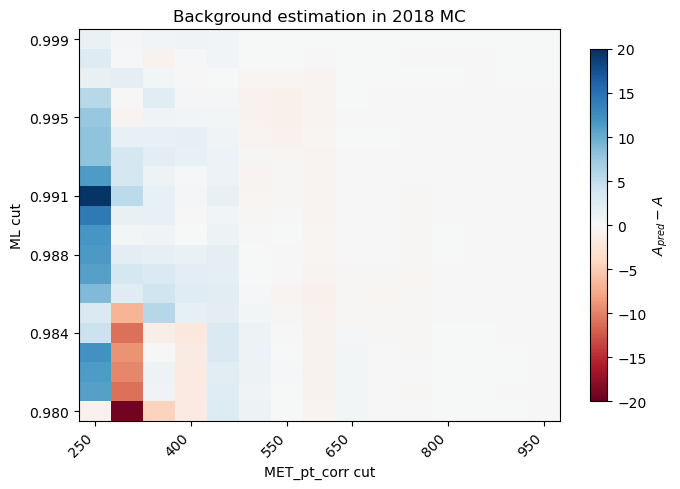

In [90]:
X_b = -table['200.00,0.00']['delta_A']
X_b = X_b.loc[250:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
# absmax = np.nanmax(np.abs(C))
absmax = 20

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-absmax, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


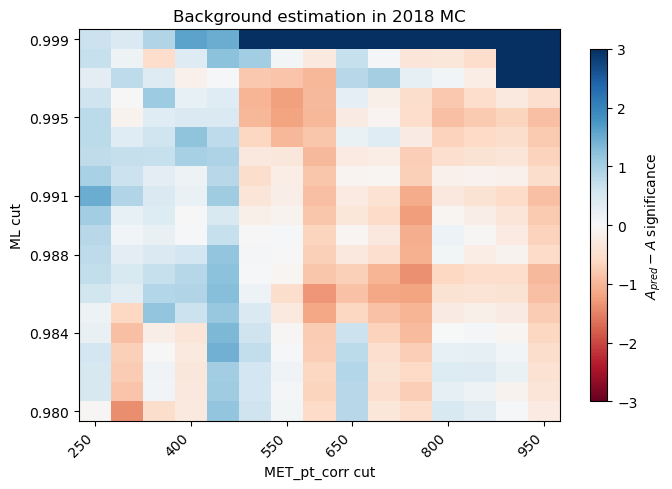

In [92]:
X_b = -table['200.00,0.00']['delta_A'] / table['200.00,0.00']['delta_A_unc']
X_b = X_b.loc[250:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-3, vmax=3, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$ significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


In [76]:
table['200.00,0.00']['delta_A_unc'].loc[:,0.98:]

,0.980,0.981,0.982,0.983,0.984,0.985,0.986,0.987,0.988,0.989,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999
50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
250.0,23.098654,22.318916,22.050399,21.744107,20.233236,18.320307,15.423690,15.048119,14.668342,14.032622,13.642423,13.212378,11.693187,10.706663,9.915158,9.470152,8.973873,4.928259,3.617078,2.142222
300.0,13.846860,12.884241,12.778697,12.615819,12.299075,11.005653,7.289636,7.063364,6.851791,6.520666,6.315128,5.969835,5.462011,4.901185,4.515182,4.198837,3.880138,2.399786,1.885016,1.029231
350.0,8.654249,7.229716,7.153373,7.018769,6.891151,4.726291,4.464801,4.353422,4.241910,4.080826,3.878271,3.723382,3.415439,3.049572,2.754818,2.391631,2.088558,1.502700,1.159998,0.727425
400.0,5.682288,5.651468,5.645099,5.581071,5.548109,2.853104,2.671920,2.566808,2.508321,2.444137,2.274015,2.158530,2.055900,1.682972,1.503839,1.385613,1.363804,0.926387,0.740903,0.499350
450.0,2.254814,2.244806,2.238198,2.136367,2.110514,1.852428,1.756650,1.620876,1.612376,1.523612,1.517270,1.351678,1.325936,1.216275,1.093223,1.087312,1.072761,0.746893,0.524999,0.485858
500.0,1.729743,1.723593,1.718901,1.662776,1.649383,1.322956,1.309636,1.127809,1.120118,1.111444,1.107342,1.098780,1.083632,0.956573,0.802571,0.800367,0.786338,0.535733,0.139748,0.036106


In [77]:
table['200.00,0.00']['delta_A'].loc[:,0.98:]

,0.980,0.981,0.982,0.983,0.984,0.985,0.986,0.987,0.988,0.989,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999
50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
250.0,0.876086,-11.038287,-11.362457,-12.136133,-4.302778,-2.993316,-8.826523,-10.941296,-11.460455,-11.765374,-14.333556,-19.590043,-11.310147,-8.060897,-8.110278,-7.583644,-5.576057,-1.553434,-2.526473,-1.360340
300.0,19.362012,11.088536,9.736526,8.908406,11.083703,6.807679,-2.483190,-3.462275,-2.134026,-0.611417,-1.512732,-5.405141,-3.510501,-3.505225,-1.666165,0.479594,0.089940,-1.878358,-0.304600,-0.466428
350.0,4.553017,-0.786241,-0.973294,0.142567,1.381941,-5.627849,-3.956430,-2.971995,-1.874085,-0.910792,-1.626383,-1.671197,-1.083259,-2.101877,-1.657863,-0.864606,-2.289791,-0.563846,0.638178,-0.659138
400.0,1.726993,1.782694,1.861763,1.685987,2.172901,-1.841831,-2.411858,-2.187387,-1.387709,-0.084618,0.028443,-0.453433,-0.296863,-1.657207,-1.798788,-0.642564,-0.323923,0.144941,-0.283641,-0.806253
450.0,-2.677140,-2.370132,-2.323262,-3.098207,-2.835771,-2.103507,-2.224366,-1.992720,-1.921601,-1.067111,-0.731930,-1.438427,-1.109569,-1.132825,-0.862331,-0.490558,-0.379604,-0.024943,-0.651924,-0.721932
500.0,-1.060201,-0.929366,-0.954876,-1.228718,-1.011900,-0.590899,-0.231890,-0.051352,-0.074152,0.002995,0.199193,0.417719,0.560545,0.301464,0.520988,0.793098,0.796029,0.428701,-0.146447,-0.132898


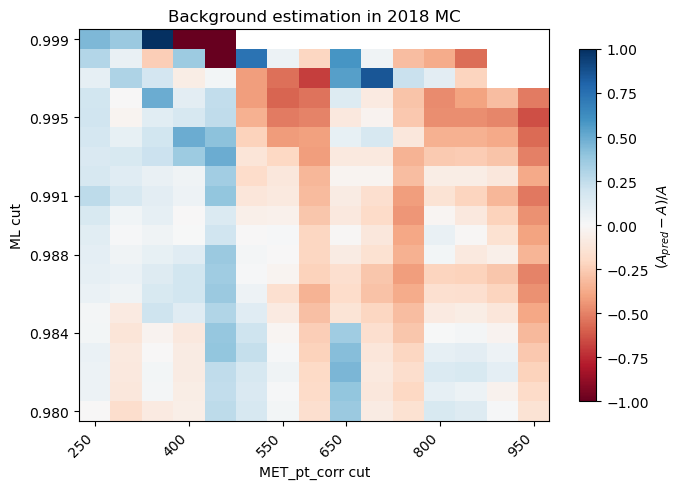

In [93]:
X_b = -table['200.00,0.00']['delta_A'] / table['200.00,0.00']['bkg_NA']
X_b = X_b.loc[250:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(A_{pred} - A) / A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


In [94]:
-table['200.00,0.00']['delta_A'] / table['200.00,0.00']['bkg_NA']

,0.001,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.010,...,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999
50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
250.0,-0.250915,-0.106814,-0.093702,-0.127636,-0.079551,-0.073039,-0.108052,-0.105290,-0.091822,-0.090103,...,0.157467,0.260892,0.169401,0.149449,0.175568,0.201521,0.187528,0.091563,0.293940,0.446717
300.0,-0.111789,-0.161122,-0.113037,-0.105171,-0.054296,-0.043165,-0.071926,-0.074286,-0.065529,-0.061453,...,0.036621,0.165663,0.123134,0.157908,0.081542,-0.026030,-0.006329,0.308774,0.074850,0.369030
350.0,-0.339928,-0.216263,-0.186052,-0.144793,-0.091459,-0.077180,-0.098262,-0.085419,-0.080174,-0.085149,...,0.087119,0.104144,0.077981,0.210978,0.188161,0.111646,0.498846,0.181722,-0.242198,3.745919
400.0,-0.448650,-0.169481,-0.171585,-0.121585,-0.126074,-0.113612,-0.114535,-0.117500,-0.113617,-0.111067,...,-0.002720,0.052360,0.040033,0.363054,0.496620,0.169057,0.102734,-0.072038,0.360313,-2.189473
450.0,-0.526333,-0.149190,-0.091653,-0.042114,-0.048711,-0.044168,-0.058908,-0.072251,-0.072511,-0.069170,...,0.145124,0.397696,0.350255,0.494548,0.408829,0.250362,0.246264,0.024701,-12.481970,-1.497780
500.0,-0.672180,-0.158191,-0.165598,-0.092679,-0.080722,-0.069064,-0.094923,-0.099449,-0.097148,-0.095140,...,-0.055719,-0.124392,-0.183956,-0.131616,-0.232004,-0.358377,-0.417384,-0.416325,0.737177,inf


In [79]:
table['200.00,0.00']['bkg_NA'].loc[:,0.98:]

,0.980,0.981,0.982,0.983,0.984,0.985,0.986,0.987,0.988,0.989,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999
50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
250.0,221.867772,201.613365,191.859569,181.877345,172.128207,156.347307,135.689529,123.769605,115.232904,102.784365,91.025532,75.088618,66.765363,53.937351,46.194592,37.632036,29.734512,16.965697,8.595192,3.045194
300.0,110.561677,98.124372,92.923057,88.174700,83.798687,73.175374,58.148480,52.792231,50.384510,46.413111,41.307445,32.627397,28.509673,22.197853,20.433185,18.424925,14.210689,6.083279,4.069455,1.263931
350.0,48.945633,41.403494,39.298697,38.398994,36.608391,26.818053,24.887768,23.639737,22.985421,21.390246,18.668432,16.046986,13.891297,9.962547,8.810862,7.744162,4.590174,3.102797,2.634947,0.175962
400.0,24.805005,23.492613,22.568686,21.405479,20.356820,14.781479,12.443476,11.544994,11.450318,11.415090,10.455856,8.659912,7.415427,4.564631,3.622065,3.800880,3.153011,2.012020,0.787207,-0.368240
450.0,10.174043,9.718802,9.212263,7.906867,7.325937,7.082588,5.974842,5.586043,5.180383,5.305827,5.043485,3.616900,3.167894,2.290630,2.109270,1.959396,1.541453,1.009815,-0.052229,-0.482001
500.0,6.457814,6.143914,5.794805,5.202666,4.925190,4.778010,4.550959,4.368175,4.067053,3.727461,3.574971,3.358071,3.047175,2.290486,2.245600,2.213025,1.907184,1.029727,0.198659,0.000000


In [97]:
table['200.00,0.00']['noncl'].loc[250:,0.98:] - table['200.00,0.00']['noncl_unc'].loc[250:,0.98:]

,0.980,0.981,0.982,0.983,0.984,0.985,0.986,0.987,0.988,0.989,0.990,0.991,0.992,0.993,0.994,0.995,0.996,0.997,0.998,0.999
250.0,-0.099967,-0.058694,-0.058768,-0.056396,-0.094009,-0.099176,-0.051782,-0.037721,-0.033075,-0.028088,-0.001258,0.068165,-0.017715,-0.060953,-0.052685,-0.067137,-0.131013,-0.216002,-0.206155,-0.457888
300.0,0.067964,-0.006308,-0.021064,-0.030330,0.001753,-0.045643,-0.086426,-0.074350,-0.097617,-0.128571,-0.120026,-0.037373,-0.084847,-0.086723,-0.151343,-0.198183,-0.265697,-0.182435,-0.416369,-0.680539
350.0,-0.068820,-0.158548,-0.161233,-0.178476,-0.144132,0.002938,-0.044778,-0.078144,-0.115767,-0.155054,-0.135776,-0.148014,-0.184166,-0.149896,-0.173535,-0.224319,-0.130074,-0.381194,-0.104149,-14.972041
400.0,-0.144357,-0.147365,-0.148046,-0.162463,-0.137950,-0.089549,-0.058269,-0.070522,-0.121527,-0.208111,-0.214249,-0.208276,-0.247124,-0.123389,-0.098152,-0.247533,-0.367523,-0.357868,-0.900480,0.000000
450.0,-0.011551,-0.038530,-0.046812,0.025035,-0.004228,-0.035985,-0.023928,-0.029205,-0.047463,-0.139209,-0.195975,-0.111869,-0.204893,-0.281893,-0.305874,-0.433496,-0.609401,-0.732569,0.000000,0.000000
500.0,-0.145282,-0.169503,-0.178247,-0.155031,-0.195223,-0.185504,-0.250813,-0.249286,-0.261912,-0.297147,-0.237708,-0.164317,-0.109106,-0.233546,-0.047509,0.118233,0.166357,0.105910,-0.405355,0.000000
550.0,-0.264548,-0.286160,-0.287887,-0.316899,-0.317665,-0.184944,-0.099007,-0.318580,-0.375863,-0.417177,-0.368756,-0.331459,-0.363683,-0.279701,0.179333,0.306020,0.373894,0.258796,-0.638230,0.000000
600.0,-0.072808,-0.045543,-0.052445,-0.013884,-0.000787,0.116481,0.173740,0.015829,-0.027257,-0.042225,0.034084,0.070846,0.065268,0.158633,0.118081,0.242071,0.280119,0.480512,-0.373342,0.000000
650.0,-0.234980,-0.268537,-0.296624,-0.331348,-0.384260,-0.048509,0.010240,-0.031550,-0.156213,-0.273671,-0.156043,-0.207388,-0.300541,-0.241599,-0.366044,-0.267903,-0.389267,-0.433381,-0.705921,0.000000
700.0,-0.120293,-0.085750,-0.110301,-0.089048,-0.036537,0.018867,0.111277,0.077853,-0.105952,-0.195534,-0.085016,-0.139562,-0.371085,-0.304746,-0.359646,-0.399509,-0.370130,-0.642547,-0.806298,0.000000


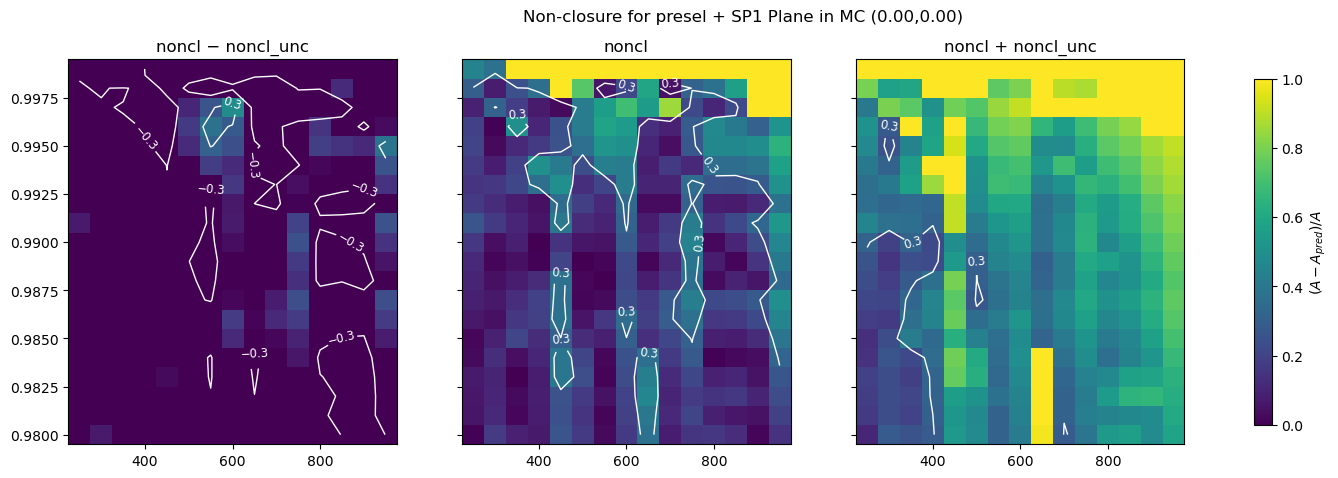

In [95]:
def plot_updown(Z_noncl_minus, Z_noncl, Z_noncl_plus, suptitle):
    # Common contour levels
    base_levels = [-0.30, 0.30]
    global_max = np.nanmax([
        np.nanmax(Z_noncl_minus.values),
        np.nanmax(Z_noncl.values),
        np.nanmax(Z_noncl_plus.values)
    ])
    levels = [lv for lv in base_levels if lv <= global_max]

    # Shared color scale
    vmin =  0
    vmax =  1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(suptitle)

    # ---------------- LEFT: noncl - noncl_unc ----------------
    ax = axes[0]
    ax.set_title("noncl − noncl_unc")
    pcm0 = ax.pcolormesh(
        Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont0 = ax.contour(
            Z_noncl_minus.index, Z_noncl_minus.columns, Z_noncl_minus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont0, fontsize="smaller")
    # ax.set_xlim(0., 0.5)
    # ax.set_ylim(0., 0.5)
    # ax.set_xlabel("leading_vtx_ML1 cut")
    # ax.set_ylabel("leading_vtx_ML2 cut")

    # ---------------- MIDDLE: noncl ----------------
    ax = axes[1]
    ax.set_title("noncl")
    pcm1 = ax.pcolormesh(
        Z_noncl.index, Z_noncl.columns, Z_noncl.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont1 = ax.contour(
            Z_noncl.index, Z_noncl.columns, Z_noncl.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont1, fontsize="smaller")
    # ax.set_xlim(0., 0.5)
    # ax.set_ylim(0., 0.5)
    # ax.set_xlabel("leading_vtx_ML1 cut")

    # ---------------- RIGHT: noncl + noncl_unc ----------------
    ax = axes[2]
    ax.set_title("noncl + noncl_unc")
    pcm2 = ax.pcolormesh(
        Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
        cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"
    )
    if levels:
        cont2 = ax.contour(
            Z_noncl_plus.index, Z_noncl_plus.columns, Z_noncl_plus.T,
            levels=levels, colors="white", linewidths=1.0, linestyles="solid"
        )
        ax.clabel(cont2, fontsize="smaller")
    # ax.set_xlim(0., 0.5)
    # ax.set_ylim(0., 0.5)
    # ax.set_xlabel("leading_vtx_ML1 cut")

    # Shared colorbar
    cbar = fig.colorbar(pcm2, ax=axes.ravel().tolist(), shrink=0.90)
    cbar.ax.set_ylabel(r"$(A - A_{pred}) / A$")

    plt.show()


noncl          =  table['200.00,0.00']['noncl'].loc[250:,0.98:]
noncl_plus1s   =  table['200.00,0.00']['noncl'].loc[250:,0.98:] + table['200.00,0.00']['noncl_unc'].loc[250:,0.98:]
noncl_minus1s  =  table['200.00,0.00']['noncl'].loc[250:,0.98:] - table['200.00,0.00']['noncl_unc'].loc[250:,0.98:]
plot_updown(noncl_minus1s, noncl, noncl_plus1s, suptitle=f"Non-closure for presel + SP1 Plane in MC ({key})")

### Overall Picture

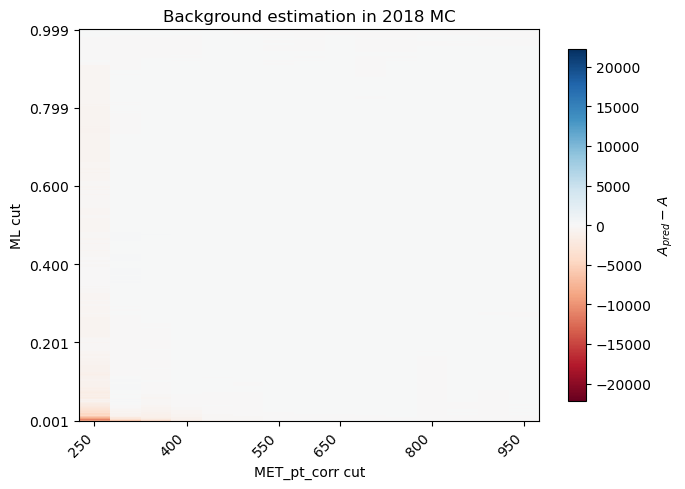

In [98]:
X_b = -table['200.00,0.00']['delta_A']
X_b = X_b.loc[250:,:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
absmax = np.nanmax(np.abs(C))

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-absmax, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


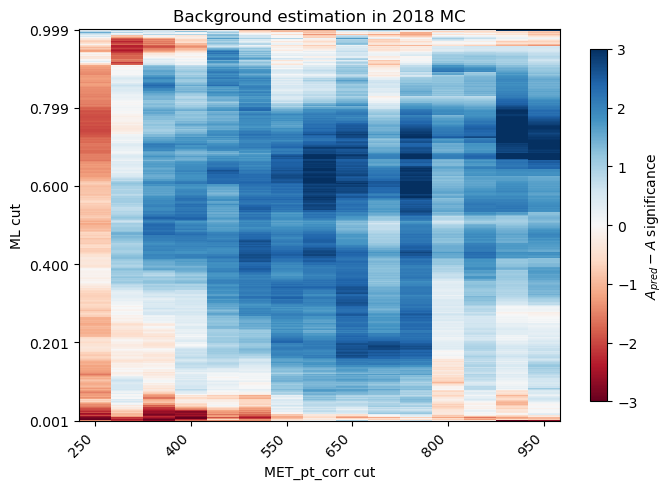

In [99]:
X_b = -table['200.00,0.00']['delta_A'] / table['200.00,0.00']['delta_A_unc']
X_b = X_b.loc[250:, :]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-3, vmax=3, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$A_{pred} - A$ significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


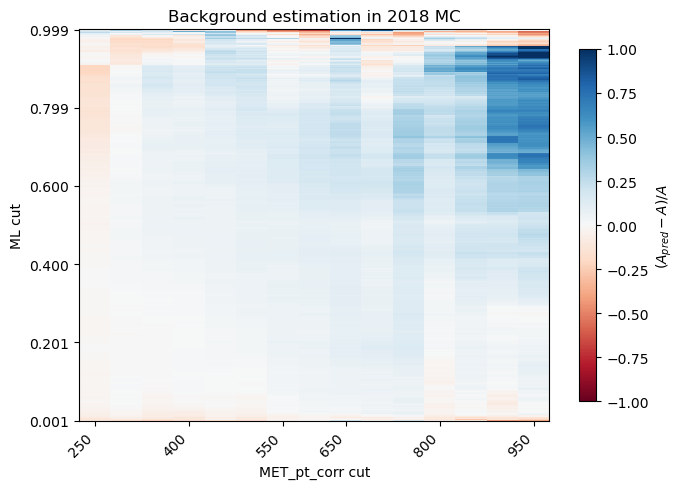

In [101]:
X_b = -table['200.00,0.00']['delta_A'] / table['200.00,0.00']['bkg_NA']
X_b = X_b.loc[250:, :]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="RdBu", vmin=-1, vmax=+1, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'$(A_{pred} - A) / A$')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title("Background estimation in 2018 MC")

fig.tight_layout()
plt.show()


### Significance

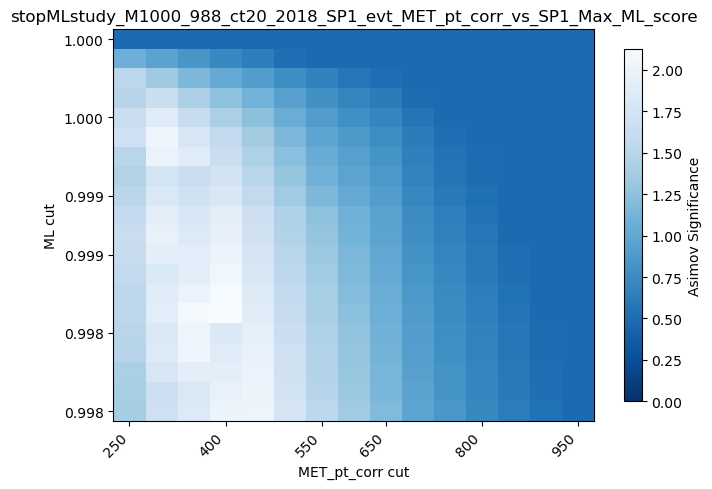

In [112]:
X_b = table['200.00,0.00']['Z_A']
X_b = X_b.loc[250:, 0.998:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
absmax = np.nanmax(np.abs(C))

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="Blues_r", vmin=0, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'Asimov Significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title(SAMPLE)

fig.tight_layout()
plt.show()


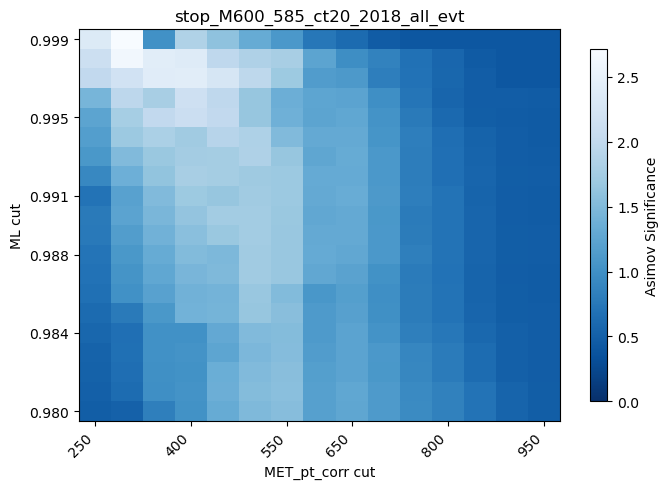

In [85]:
X_b = table['200.00,0.00']['Z_noncl_A']
X_b = X_b.loc[250:, 0.98:]

x = X_b.index.to_numpy(dtype=float)
y = X_b.columns.to_numpy(dtype=float)

x_edges = edges_from_centers(x)     # len = Nx + 1
y_edges = edges_from_centers(y)     # len = Ny + 1

C = X_b.T.to_numpy()                # (Ny, Nx)
absmax = np.nanmax(np.abs(C))

fig, ax = plt.subplots(figsize=(7, 5))

pcm = ax.pcolormesh(
    x_edges, y_edges, C,
    cmap="Blues_r", vmin=0, vmax=+absmax, shading="flat"
)

ax.set_xticks(pick_ticks(x, 6))
ax.set_yticks(pick_ticks(y, 6))

ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.ax.set_ylabel(r'Asimov Significance')

ax.set_xlabel("MET_pt_corr cut")
ax.set_ylabel("ML cut")
ax.set_title(f"stop_M600_585_ct20_2018_all_evt")

fig.tight_layout()
plt.show()
